<!-- Note

Regridding takes 1 second per panel when running with DASK as

- n_workers = 5 
- threads_per_worker = 4
- memory_limit = "30GiB" - memory per worker -->

In [92]:
from dask.distributed import Client, LocalCluster
from scipy.interpolate import griddata
import xarray as xr
import time 

<!-- # Spin up Dask -->

# Setup

In [ ]:
# -------------------------------------
# Set up Dask if doing parllel processing
# -------------------------------------

In [ ]:
# Use this if you just want use Dask to grab the resources available on the machine 
cluster = LocalCluster()
client = Client(cluster)

In [24]:
# Control Dask cluster parameters here
n_workers = 4 
threads_per_worker = 16
memory_limit = "50GiB"

cluster = LocalCluster(n_workers=n_workers,threads_per_worker=threads_per_worker,memory_limit=memory_limit)
client = Client(cluster)

/localhome/phymku/.conda/envs/analysis/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45565 instead
  warnings.warn(


In [ ]:
client

In [ ]:
# Clean up Dask if needed
client.shutdown()
cluster.close() 

<!-- # User choices for reading in raw data, regridding and processing -->

In [ ]:
# ------------------------------
# End Dask setup
# ------------------------------

In [9]:
# ----------------------------------------------------------------
# User changes
# ----------------------------------------------------------------

In [75]:
# Read in unstructured flat map data to regrid
# Currently programmed to expect either one file

path_reduced_data = '/uolstore/Research/b/b0252/Data/cam6_2_011_CONUS/CONUS_RR_PROCESSED_DATA/reduced_data/'
path_in = path_reduced_data + 'maps/'

file = 'ilev_5_rr_extracted_FWmaHIST_ne0CONUSne30x8_ne0CONUSne30x8_mt12_no_conus_gravity_waves.cam.h0.2010-12-01-00000.nc'

In [76]:

# Choice of lon representation in dataset.
lon_range_type = 'n180_to_p180' # Options: 'O_to_360' ; 'n180_to_p180'

# Variables to extract from main dataset. Needs lat lon for regridding.
# Options: Any variable available from raw output in files from file_list.
var_list_selection = ['OMEGA','T','lat','lon']

# Variables to actually regrid, i.e., you don't want lat or lon in this list!
var_list_for_regridding = ['w']

# Calculate w from T and OMEGA. If False, use OMEGA directly.
calculate_w_from_omega = True                 

# Extraction of time from raw data read in.
itime_list_selection = [0,1]

# Saves regridded file to netcdf
save_regridding = False

# Path to save regridded data, ignored in code if save_regridding = False
path_to_save_regrid = 'usr_path'

# String that goes at the front of model name when saving regridded file to netcdf
model_str = 'nonrr' 

# Regridding extents (will just be ignored if regridding = False

rxL = -150 # 'regrid' x lower bound
rxU = -50 # rx upper bound
ryL = 20
ryU = 55
dr = 0.1 # Grid cell size


# ----------------------------------------------------------------
# End user changes
# ----------------------------------------------------------------


<!-- # Ingest and reduce data -->

In [77]:
ds = xr.open_mfdataset(path_in+file,parallel=True)[var_list_selection]

In [78]:
# Inspect dataset
print(f'ds takes up {ds.nbytes/1e9:.2f} Gb of memory')
ds

ds takes up 0.04 Gb of memory


<xarray.Dataset> Size: 36MB
Dimensions:  (time: 24, lev: 1, ncol: 174098)
Coordinates:
  * lev      (lev) float64 8B 5.303e-05
  * time     (time) object 192B 2010-12-01 00:00:00 ... 2010-12-01 23:00:00
Dimensions without coordinates: ncol
Data variables:
    OMEGA    (time, lev, ncol) float32 17MB dask.array<chunksize=(24, 1, 174098), meta=np.ndarray>
    T        (time, lev, ncol) float32 17MB dask.array<chunksize=(24, 1, 174098), meta=np.ndarray>
    lat      (ncol) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
    lon      (ncol) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
Attributes: (12/13)
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne0CONUSne30x8_ne0CONUSne30x8_mt12_no_conus_g...
    logname:           nadavis
    ...                ...
    initial_file:      /glade/p/cgd/amp/pel/inic/waccm-conus-FW-nlev110.i.nc
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/se/ne30x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_1
    history:           Mon Jul 21 19:15:43 2025: ncks -d lev,5 -v T,OMEGA,U,V...
    NCO:               netCDF Operators version 5.1.4 (Homepage = http://nco....

In [79]:
# Select data to regrid
tic = time.time()
ds0 = ds.isel(time=itime_list_selection)
toc = time.time()
print(f'That took {toc-tic:.2e} seconds')

That took 1.57e-03 seconds


In [80]:
ds0

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 2, lev: 1, ncol: 174098)
Coordinates:
  * lev      (lev) float64 8B 5.303e-05
  * time     (time) object 16B 2010-12-01 00:00:00 2010-12-01 01:00:00
Dimensions without coordinates: ncol
Data variables:
    OMEGA    (time, lev, ncol) float32 1MB dask.array<chunksize=(2, 1, 174098), meta=np.ndarray>
    T        (time, lev, ncol) float32 1MB dask.array<chunksize=(2, 1, 174098), meta=np.ndarray>
    lat      (ncol) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
    lon      (ncol) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
Attributes: (12/13)
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne0CONUSne30x8_ne0CONUSne30x8_mt12_no_conus_g...
    logname:           nadavis
    ...                ...
    initial_file:      /glade/p/cgd/amp/pel/inic/waccm-conus-FW-nlev110.i.nc
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/se/ne30x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_1
    history:           Mon Jul 21 19:15:43 2025: ncks -d lev,5 -v T,OMEGA,U,V...
    NCO:               netCDF Operators version 5.1.4 (Homepage = http://nco....

In [81]:
# Select choice of longitude axis from -180 to 180 or from 0 - 360 and sort out data
if lon_range_type == 'O_to_360':
    None
if lon_range_type == 'n180_to_p180':
    ds0['lon'] = xr.where(ds0['lon'] > 180, ds0['lon'] - 360, ds0['lon'])

In [82]:
print(ds0.nbytes/1e9)
print(ds0)

0.00557116
<xarray.Dataset> Size: 6MB
Dimensions:  (time: 2, lev: 1, ncol: 174098)
Coordinates:
  * lev      (lev) float64 8B 5.303e-05
  * time     (time) object 16B 2010-12-01 00:00:00 2010-12-01 01:00:00
Dimensions without coordinates: ncol
Data variables:
    OMEGA    (time, lev, ncol) float32 1MB dask.array<chunksize=(2, 1, 174098), meta=np.ndarray>
    T        (time, lev, ncol) float32 1MB dask.array<chunksize=(2, 1, 174098), meta=np.ndarray>
    lat      (ncol) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
    lon      (ncol) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
Attributes: (12/13)
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne0CONUSne30x8_ne0CONUSne30x8_mt12_no_conus_g...
    logname:           nadavis
    ...                ...
    initial_file:      /glade/p/cgd/amp/pel/inic/waccm-conus-FW-nlev110.i.nc
    topography_file:   /glade/p/cesmdata/

In [ ]:
# Load dataset into memory
tic = time.time()

ds1 = ds0.compute()
toc = time.time()
print(f'That took {toc-tic:.2e} seconds')

That took 2.68e-02 seconds


In [84]:
print(ds1.nbytes/1e9)
print(ds1)

0.00557116
<xarray.Dataset> Size: 6MB
Dimensions:  (time: 2, lev: 1, ncol: 174098)
Coordinates:
  * lev      (lev) float64 8B 5.303e-05
  * time     (time) object 16B 2010-12-01 00:00:00 2010-12-01 01:00:00
Dimensions without coordinates: ncol
Data variables:
    OMEGA    (time, lev, ncol) float32 1MB -4.791e-07 -1.871e-07 ... 1.236e-06
    T        (time, lev, ncol) float32 1MB 291.0 285.8 282.8 ... 301.5 297.4
    lat      (ncol) float64 1MB 6.166 6.049 5.86 5.742 ... 47.22 47.31 47.14
    lon      (ncol) float64 1MB -125.6 -125.3 -124.6 ... -61.01 -60.51 -60.71
Attributes: (12/13)
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              FWmaHIST_ne0CONUSne30x8_ne0CONUSne30x8_mt12_no_conus_g...
    logname:           nadavis
    ...                ...
    initial_file:      /glade/p/cgd/amp/pel/inic/waccm-conus-FW-nlev110.i.nc
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/se/ne30x...
    m

In [85]:
def converta_omega_to_w(omega,T,pressure): # Convert Pa/s to m/s (take care with units!)
    """_summary_
    Takes in data arrays of:
    
    omega - vertical velocity in Pa/s
    T - temperature in Kelvin
    pressure - atmospheric pressure in hPa (take care with units!)
    
    returns vertical velocity data array in m/s
    """
    
    # Calculate mass density: kg m^-3
    # Conversion constants
    R = 287.058 # J/ kg^-1 K^-1 => m^2 s^-2 K^-1
    to_Pa = 100 # convert from hPa to Pa. Pa => kg m^-1 s^-2
    rho = pressure*to_Pa/(R*T) # Units: kg m^-1 s^-2 * m^-2 s^2 K * K^-1 => kg m^-3

    g = 9.80665 # m s^-2
    w = -omega/(rho*g) # Units: kg m^-1 s^-2 * s^-1 * kg^-1 m^3 * m^-1 s^2 => m s^-1
    
    return w

if calculate_w_from_omega == True:
    ds1['w'] = converta_omega_to_w(ds1['OMEGA'],ds1['T'],ds1['lev'])

# Regrid

In [87]:
# Get regridding geometry

x=ds1['lon'].squeeze().values # Extract dimension data
y=ds1['lat'].squeeze().values

lat2d = np.arange(ryL, ryU + dr, dr) # create grid coordinates
lon2d = np.arange(rxL, rxU + dr, dr)
X, Y = np.meshgrid(lon2d, lat2d) # create grid
toc = time.time()

In [88]:
# Print controls

print('save_regridding',save_regridding)
print('path_to_save_regrid',path_to_save_regrid)
print('model_str',model_str)
print('lon_range_type',lon_range_type)
print('var_list_selection',var_list_selection)
print('var_list_for_regridding',var_list_for_regridding)
print('\ntime selection\n',ds1.time.values)
print('\nrxL',rxL)
print('rxU',rxU)
print('ryL',ryL)
print('ryU',ryU)
print('dr',dr)

save_regridding False
path_to_save_regrid usr_path
model_str nonrr
lon_range_type n180_to_p180
var_list_selection ['OMEGA', 'T', 'lat', 'lon']
var_list_for_regridding ['w']

time selection
 [cftime.DatetimeNoLeap(2010, 12, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2010, 12, 1, 1, 0, 0, 0, has_year_zero=True)]

rxL -150
rxU -50
ryL 20
ryU 55
dr 0.1


In [ ]:
# ------------------------------------------------------------------------
# Perform regridding
# ------------------------------------------------------------------------
ds_regridded_list = []

grand_tic = time.time()
for var in var_list_for_regridding:
    for itime in range(len(itime_list_selection)):
            
        ds_for_regridding = ds1[var].isel(time=itime).squeeze() # isolate time and variable for regridding

        print(f'processing var {var} time {ds1.time.isel(time=itime).values}')

        regrid_tic = time.time()

        regridded_data  = griddata((x,y), ds_for_regridding, (X, Y), method='linear') # regrid ds_for_regridding
        ds_regridded = xr.Dataset({
                                var: (["lat", "lon"], regridded_data),
                            },
                            coords={"lat": lat2d, "lon": lon2d}) # add regridded data to new dataset

        ds_regridded['time'] = ds_for_regridding.time # Add time information to dataset
        ds_regridded = ds_regridded.set_coords('time').expand_dims('time')
        ds_regridded['lev'] = ds_for_regridding.lev # Add lev information to dataset
        ds_regridded = ds_regridded.set_coords('lev').expand_dims('lev')
        regrid_toc = time.time()
        print(f'regridding took {regrid_toc-regrid_tic:.2f} seconds')
        
        ds_regridded_list.append(ds_regridded) # Append regridded dataset to list

        if save_regridding:
            fname = f'{model_str}_{var}_{ds_regridded.time.values.item().strftime("%Y-%m-%d_%H:%M:%S")}.nc'
            print(f'Saving {path_to_save_regrid+fname}')
            ds_regridded.to_netcdf(path_to_save_regrid+fname)

grand_toc = time.time()
print(f'That whole cell took {grand_toc - grand_tic:.2f} seconds')

processing var w time 2010-12-01 00:00:00
regridding took 2.98 seconds
processing var w time 2010-12-01 01:00:00
regridding took 2.94 seconds
That whole cell took 5.92 seconds


In [90]:
# Inspect regridded data
ds_regridded_list[1]['w']

<xarray.DataArray 'w' (lev: 1, time: 1, lat: 351, lon: 1001)> Size: 3MB
array([[[[ 0.25787531,  0.27666998,  0.29619336, ...,  0.94815833,
           0.9378398 ,  0.89950075],
         [ 0.27606446,  0.28773047,  0.30623646, ...,  0.91380151,
           0.87546246,  0.83712341],
         [ 0.29425362,  0.30591963,  0.31758563, ...,  0.85142418,
           0.81308513,  0.77474608],
         ...,
         [ 2.28445944,  2.19265699,  2.04913343, ..., -0.59131156,
          -0.75462572, -0.72612637],
         [ 2.30754555,  2.2283189 ,  2.08479534, ..., -0.61414119,
          -0.58436971, -0.5635563 ],
         [ 2.33066275,  2.26398081,  2.15307567, ..., -0.52575996,
          -0.50041569, -0.43420765]]]], shape=(1, 1, 351, 1001))
Coordinates:
  * lat      (lat) float64 3kB 20.0 20.1 20.2 20.3 20.4 ... 54.7 54.8 54.9 55.0
  * lon      (lon) float64 8kB -150.0 -149.9 -149.8 -149.7 ... -50.2 -50.1 -50.0
  * lev      (lev) float64 8B 5.303e-05
  * time     (time) object 8B 2010-12-01 01:00:00

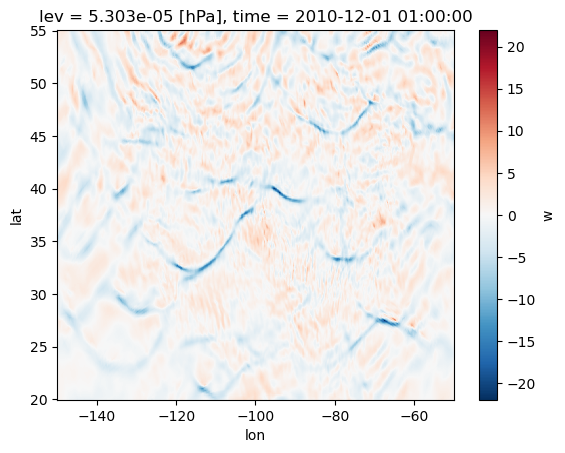

In [91]:
ds_regridded_list[1]['w'].plot()